# Predicting Listing Prices for Airbnb NYC, Exploring of Different Predictive Models

## Part I: Dataset, Problem Statement & Data Exploration (Visualisations and main data trends)

#### Importing Libraries

In [1]:
#importing libraries
import pandas as pd
import numpy as np
import matplotlib
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as colors
matplotlib.style.use('seaborn-v0_8')
from mpl_toolkits import mplot3d
import matplotlib.cm as cm
import plotly.express as px
import plotly.io as pio
# Set the Seaborn palette
pio.templates['seaborn-v0_8'] = pio.templates['plotly_white']
pio.templates.default = 'seaborn-v0_8'

import folium

from wordcloud import WordCloud
#for text pre-processing 
import re
import gensim
import os
from nltk.corpus import stopwords
import nltk
#downloading stopwords
nltk.download('stopwords')

#showing all outputs in a cell 
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = 'all'

[nltk_data] Downloading package stopwords to /Users/varia/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


# 1. Dataset and Problem Statement

Airbnb.inc, a peer-to-peer platform operating on a commission-based Business Model(BM), earns revenue from bookings(Airbnb, 2022; Goel,2022). A prevalent issue for numerous peer- to-peer platforms is price rigidity(Pan & Wang,2022). To ensure competitive pricing, hosts must know current value attributed to their listings and future demand. Since renters’ Willingness-to- pay (WTP) drives main pricing dynamics, it is crucial for Airbnb that hosts maintain listings’ competitiveness for a steady revenue stream via increased bookings. Due to uncompetitive listing price, the platform faced a $352mil loss in 2021 and customer dissatisfaction (Curry, 2023).

Currently, the US is Airbnb’s largest market, averaging 2,249,434 listings in 2021 (Statista,2022). Hence, this report will examine Airbnb’s listings dataset in NY sourced from InsideAirbnb (2022) to identify crucial factors influencing price and determine the best predictive model for price predictions. This will enable hosts to set ideal listing pricings, optimising supply and demand efficiency, hence, augmenting Airbnb’s revenue (Reynolds et al.,2019).

In [2]:
df = pd.read_csv('data/raw/AB_NYC_2019.csv')
print('Imported Dataset with {0} rows and {1} columns'.format(len(df), len(df.columns)))

Imported Dataset with 48895 rows and 16 columns


# 2. Data Exploration

In [3]:
#checking the dataset head to get an understanding of the data
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


Columns 'host_id' and 'host_name' have no economic meaning in predicting listings' price. Hence, they are redundant, and were dropped in the subsequent analysys.

In [4]:
#dropping the columns providing no economic meaning in the analysis, and irrelevant in building predictive models
df.drop(columns=['host_id', 'host_name'], inplace=True)

In [5]:
#checking descriptive statistics
df.describe()

,id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


In [6]:
#Information about columns: number of non-null values and data types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  str    
 2   neighbourhood_group             48895 non-null  str    
 3   neighbourhood                   48895 non-null  str    
 4   latitude                        48895 non-null  float64
 5   longitude                       48895 non-null  float64
 6   room_type                       48895 non-null  str    
 7   price                           48895 non-null  int64  
 8   minimum_nights                  48895 non-null  int64  
 9   number_of_reviews               48895 non-null  int64  
 10  last_review                     38843 non-null  str    
 11  reviews_per_month               38843 non-null  float64
 12  calculated_host_listings_count  48895 non-n

##### Interactive Scatter Mapbox Plot of Airbnb Listings in NY by Neighbourhood Group. For each listing, the price and description can be hovered over to obtain the listing's details.

In [7]:
m = folium.Map(location=[df['latitude'].mean(), df['longitude'].mean()], zoom_start=10)

colors = {'Manhattan': 'red', 'Brooklyn': 'blue', 'Queens': 'green',
          'Bronx': 'orange', 'Staten Island': 'purple'}

for _, row in df.sample(5000, random_state=28).iterrows():
    _ = folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=3,
        color=colors.get(row['neighbourhood_group'], 'gray'),
        fill=True,
        fill_opacity=0.6,
        popup=f"{row['name']}<br>Price: ${row['price']:,.0f}"
    ).add_to(m)

m

##### Interactive scatter plot displaying the relationship between price and minimum nights of the listing. It can be seen that the lower the # nights - the higher the price

In [8]:
fig = px.scatter(df, x = "minimum_nights", y = "price", 
                 color = "neighbourhood_group", hover_name = "name")
# Set the title and axis labels
fig.update_layout(title = "Relationship Between Price and Minimum Nights Required",
                  xaxis_title = "Minimum Nights Required",
                  yaxis_title = "Price")
fig.show();

##### Examining the 'neighbourhood' column. Interactive bar chart of listing counts across the 221 unique neighbourhoods.

In [9]:
## Calculating the count of each neighbourhood value
neighbourhood_counts = df['neighbourhood'].value_counts()
# Creating a bar plot of the counts
fig = px.bar(
    x = neighbourhood_counts.index, 
    y = neighbourhood_counts.values, 
    color = neighbourhood_counts.index, 
    color_discrete_sequence = px.colors.qualitative.Pastel,
    text=neighbourhood_counts.values
)
# Obtaining the total # unique neighborhoods
unique_neighborhoods = len(df['neighbourhood'].unique())
fig.update_layout(
    title = f'Count of Airbnb Listings by Neighborhood ({unique_neighborhoods} Unique Neighborhoods)',
    xaxis_title = 'Neighbourhood', 
    yaxis_title = 'Count'
)
fig.show();

##### Observing the relationship between 'neighbourhood' and 'neighbourhood_group' columns.

In [10]:
# grouping the df by neighbourhood and neighbourhood_group and obtaining the median  longitude and latitude for each group
grouped = df.groupby(['neighbourhood', 'neighbourhood_group'])[['latitude', 'longitude']].median().reset_index()

# generating a map centered on mean latitude and longitude of all listings
map = folium.Map(location=[df.latitude.mean(), 
                           df.longitude.mean()], zoom_start=11)

# iterating over each row of the grouped df and adding a marker
#for each neighbourhood
for row in grouped.itertuples():
    tooltip = f"{row.neighbourhood_group}: {row.neighbourhood}"
    _ = folium.Marker(location=[row.latitude, row.longitude], 
                  tooltip=tooltip).add_to(map)

# displaying the map
map

##### Neighborhood group encompasses the neighbourhood. This variable would need One-Hot-Encoding (OHE) resulting in 221 new columns. Training Predictive Models with neighbourhoud would result in a too long training time and, potentially, not too representative results. Therefore, this column was dropped from the subsequent analysis.

In [11]:
del df['neighbourhood']

##### Checking the number of listings for each room type and neighbourhood group

/var/folders/30/5ygxtbks68d9_2ftg_q1wr2m0000gn/T/ipykernel_62546/757005677.py:13: UserWarning: The palette list has more values (10) than needed (3), which may not be intended.
  sns.countplot(x = df['room_type'], ax = ax[0], alpha = 0.9,
/var/folders/30/5ygxtbks68d9_2ftg_q1wr2m0000gn/T/ipykernel_62546/757005677.py:25: UserWarning: The palette list has more values (10) than needed (5), which may not be intended.
  sns.countplot(x = df['neighbourhood_group'], ax = ax[1],


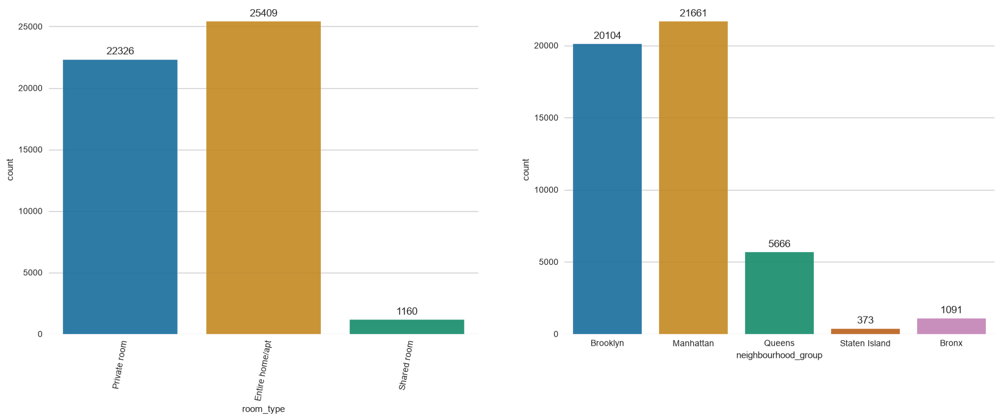

In [12]:
# checking the number of listings for each room type
#and neighbourhood group
# setting style and palette
sns.set_style('whitegrid', {'axes.edgecolor': '0', 
                            'xtick.bottom': True, 
                            'ytick.left': True, 
                            'grid.color': '.8', 
                            'axes.facecolor': 'white'})
colors = sns.color_palette('colorblind')
# creating the subplots
_, ax = plt.subplots(1, 2, figsize = (20, 7))
# plot the first subplot
sns.countplot(x = df['room_type'], ax = ax[0], alpha = 0.9,
              palette = colors, hue = df['room_type'], legend = False)
# Adding value labels for each bar
for p in ax[0].patches:
    ax[0].annotate('{:.0f}'.format(p.get_height()),
                   (p.get_x() + p.get_width() / 2., p.get_height()), 
                   ha = 'center', va = 'center', 
                   xytext = (0, 9), 
                   textcoords = 'offset points',
                   fontsize = 12)
ax[0].tick_params(axis = 'x', rotation = 80)
# plotting the second subplot
sns.countplot(x = df['neighbourhood_group'], ax = ax[1],
              alpha = 0.9, palette = colors, hue = df['neighbourhood_group'], legend = False)
# Adding value labels for each bar
for p in ax[1].patches:
    ax[1].annotate('{:.0f}'.format(p.get_height()),
                   (p.get_x() + p.get_width() / 2., p.get_height()), 
                   ha = 'center', va = 'center', 
                   xytext = (0, 9), 
                   textcoords = 'offset points',
                   fontsize=12)
plt.show();

##### Plotting the average price per room type and neighbourhood group.

/var/folders/30/5ygxtbks68d9_2ftg_q1wr2m0000gn/T/ipykernel_62546/465497925.py:20: UserWarning: The palette list has more values (10) than needed (3), which may not be intended.
  sns.barplot(x = room_type_prices.values, y = room_type_prices.index,
/var/folders/30/5ygxtbks68d9_2ftg_q1wr2m0000gn/T/ipykernel_62546/465497925.py:35: UserWarning: The palette list has more values (10) than needed (5), which may not be intended.
  sns.barplot(x = neighbourhood_prices.values, y = neighbourhood_prices.index,


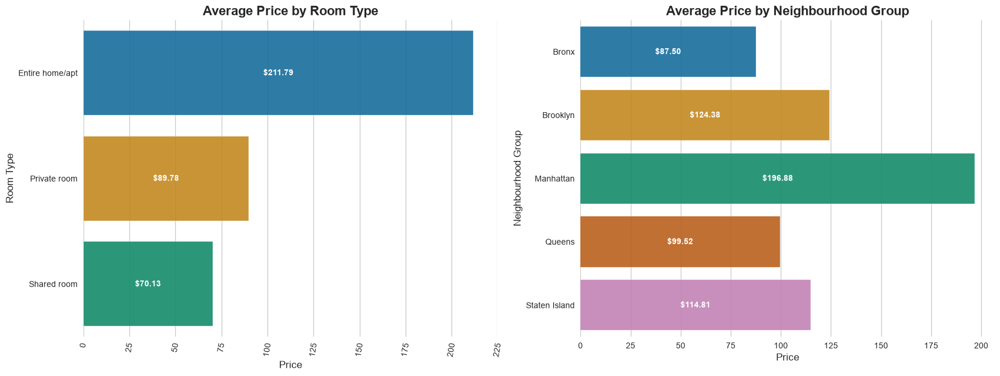

In [13]:
#Plotting the average price per room type and neighbourhood group
# setting style and colorblind palette
sns.set_style('whitegrid', {'axes.edgecolor': '0', 
                            'xtick.bottom': True, 
                            'ytick.left': True, 
                            'grid.color': '.8', 
                            'axes.facecolor': 'white'})
# setting a colorblind palette
colors = sns.color_palette('colorblind')
# creating  subplots
fig, ax = plt.subplots(1, 2, figsize = (20, 7))
# adding axis labels and title  for the 1st subplot
ax[0].set_title('Average Price by Room Type', fontsize = 16, 
                fontweight = 'bold')
ax[0].set_xlabel('Price', fontsize = 12)
ax[0].set_ylabel('Room Type', fontsize = 12)
# creating a horisontal bar chart with room types(y-axis) 
#and mean prices (x-axis)
room_type_prices = df.groupby('room_type')['price'].mean()
sns.barplot(x = room_type_prices.values, y = room_type_prices.index,
            palette = colors, hue = room_type_prices.index, legend = False, ax = ax[0], alpha = 0.9)
ax[0].set_xticks(ax[0].get_xticks())
ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation = 80)
# annotating price values on each bar in the 1st subplot
for i, v in enumerate(room_type_prices.values):
    ax[0].text(v/2, i, f'${v:.2f}', color = 'white',
               fontweight = 'bold', ha = 'center', va = 'center')
# adding a title and axis labels for the 2nd subplot
ax[1].set_title('Average Price by Neighbourhood Group', fontsize = 16, 
                fontweight = 'bold')
ax[1].set_xlabel('Price', fontsize = 12)
ax[1].set_ylabel('Neighbourhood Group', fontsize = 12)
# plotting the 2nd subplot
neighbourhood_prices = df.groupby('neighbourhood_group')['price'].mean()
sns.barplot(x = neighbourhood_prices.values, y = neighbourhood_prices.index, 
            ax = ax[1], palette = colors, hue = neighbourhood_prices.index, legend = False, alpha = 0.9)
# annotating price values on each bar in the 2nd subplot
for i, v in enumerate(neighbourhood_prices.values):
    ax[1].text(v/2, i, f'${v:.2f}', color = 'white', 
               fontweight = 'bold', ha = 'center', va = 'center')
plt.show();

##### Checking which room types are centered in which neighbourhood: geographic scatter plot of listings (longitude vs. latitude), coloured by room type.

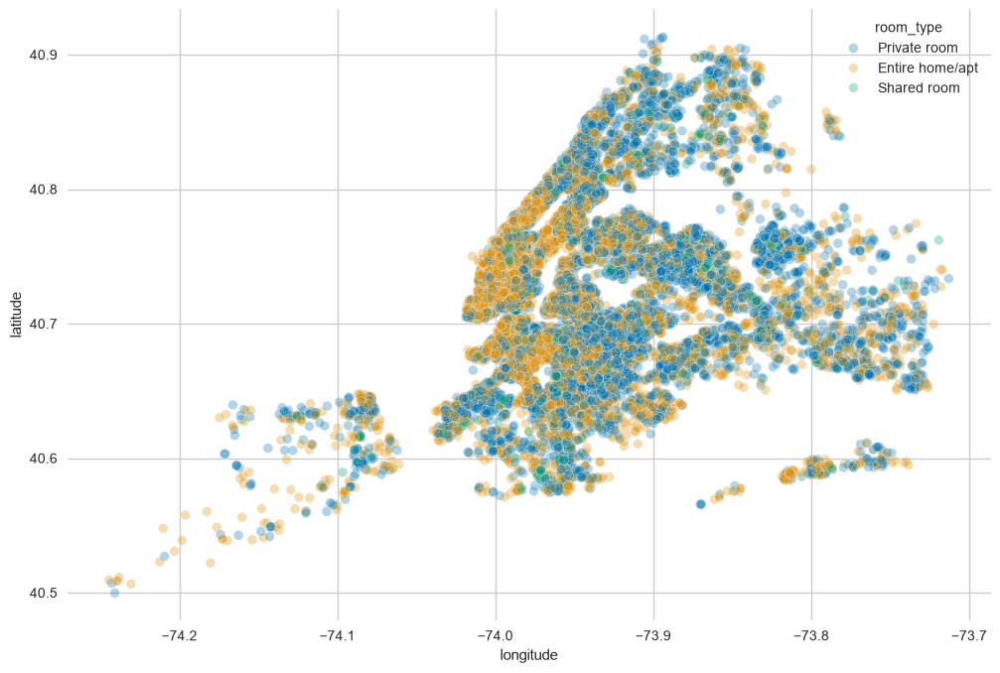

In [14]:
# setting a bright style and the  color palette 
sns.set_style('whitegrid', {'axes.edgecolor': '0', 
                            'xtick.bottom': True, 
                            'ytick.left': True, 
                            'grid.color': '.8', 
                            'axes.facecolor': 'white'})
sns.set_palette('colorblind')
plt.figure(figsize = (12,8))
sns.scatterplot(data = df, x = 'longitude',
                y = 'latitude', hue = df.room_type, alpha = 0.3)
#turning the interactive mode off and showing the plot
plt.ioff();
plt.show();

##### Plotting the Maximum and Minimum Prices per Neighbourhood Group.

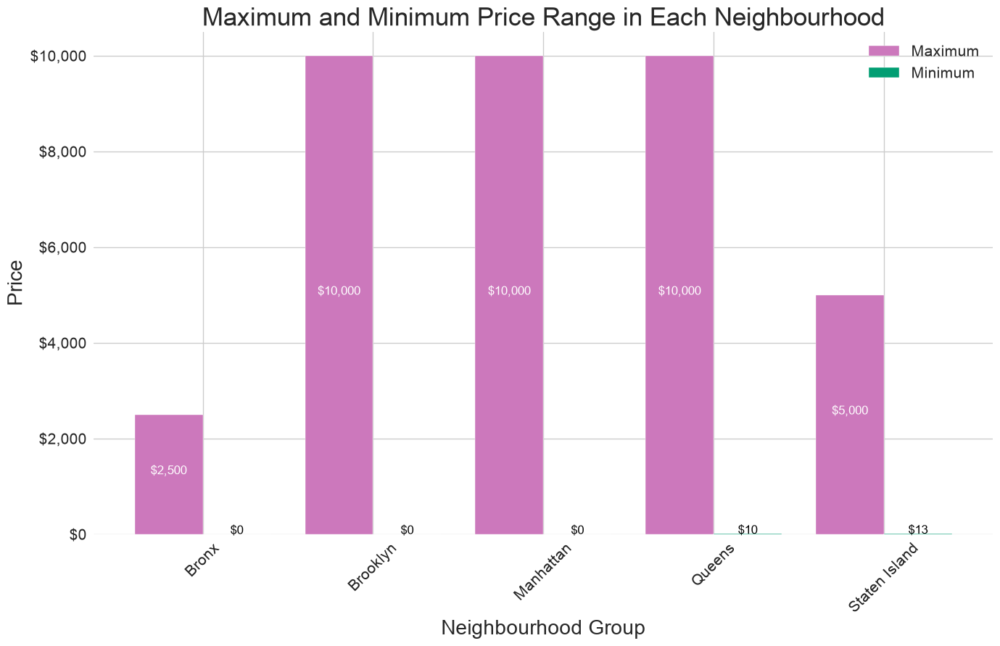

In [15]:
# Plotting the Maximum and Minimum Prices per Neighbourhood Group
Maximum = df[['neighbourhood_group',
              'price']].groupby('neighbourhood_group').max().reset_index().price.values
Minimum = df[['neighbourhood_group', 
              'price']].groupby('neighbourhood_group').min().reset_index().price.values
districts = df[['neighbourhood_group', 
                'price']].groupby('neighbourhood_group').min().reset_index().neighbourhood_group
# Setting up the plot
fig, ax = plt.subplots(figsize = (16, 9))
sns.set_palette('colorblind')
sns.set_style('whitegrid')
bar_width = 0.4
# Creating the bar chart
r = np.arange(len(districts))
plt.bar(r, Maximum, color = sns.color_palette('colorblind')[4],
        width = bar_width, edgecolor = 'white', label = 'Maximum')
plt.bar(r + bar_width, Minimum, color = sns.color_palette('colorblind')[2], 
        width = bar_width, edgecolor = 'white', label = 'Minimum')
# Adding labels and title
plt.xlabel('Neighbourhood Group', fontsize = 20)
plt.ylabel('Price', fontsize = 20)
plt.title('Maximum and Minimum Price Range in Each Neighbourhood', 
          fontsize = 25)
# Setting tick label size and rotation
plt.xticks(r + bar_width/2, districts, rotation = 45, 
           fontsize = 15)
plt.yticks(fontsize = 15)
# Addding $ sign before each value on the chart
plt.gca().yaxis.set_major_formatter('${:,.0f}'.format)
# Addding $ sign labels in the middle of each bar
for i, v in enumerate(Maximum):
    ax.text(i, v/2, '${:,.0f}'.format(v),
            fontsize = 12, color = 'white', ha = 'center')
for i, v in enumerate(Minimum):
    ax.text(i + bar_width, v/2, '${:,.0f}'.format(v), 
            fontsize = 12, color = 'black', ha = 'center')
# Adding the legend
plt.legend(fontsize = 15)
# Showing the plot
plt.show();

##### Checking the relationshib between 'neighbourhood_group'  and 'availability_365'

In [16]:
fig = px.box(df, x = 'neighbourhood_group',
             y = 'availability_365', color = 'neighbourhood_group',
             color_discrete_sequence = px.colors.qualitative.Pastel1)
fig.update_layout(title = 'Availability by Neighbourhood Group')
fig.show();

##### Plotting the wordcloud for the 'name' column to examine the most common words in the text column.

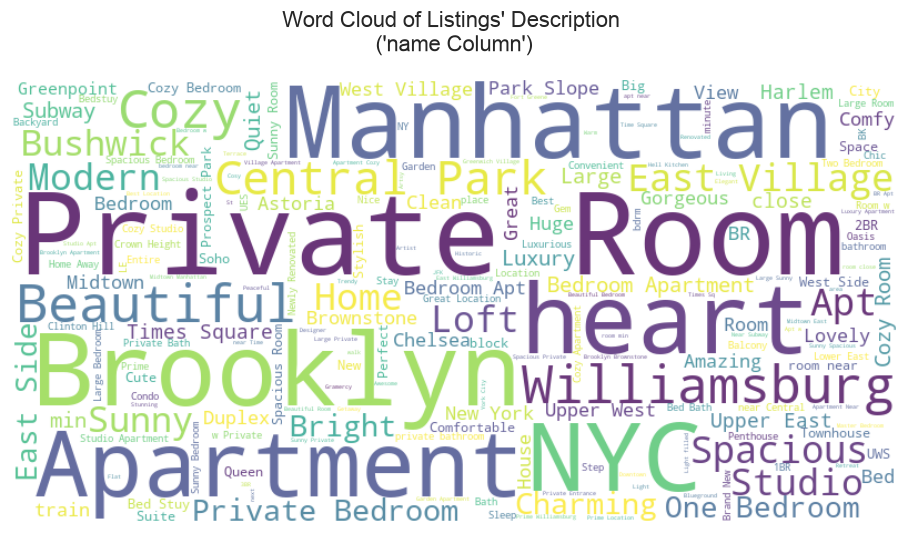

In [17]:
# Concatenating all names into a single string
all_names = ' '.join(df['name'].dropna().astype(str).tolist())
# Generating a word cloud
wordcloud = WordCloud(width = 800, height = 400,
                      background_color = 'white').generate(all_names)
# Plot the word cloud
plt.figure(figsize = (12, 6))
plt.imshow(wordcloud, interpolation = 'bilinear', alpha = 0.8)
# Addding the title and adjusting the position
plt.title('Word Cloud of Listings\' Description \n(\'name Column\')', 
          fontsize = 16, pad = 20)
plt.subplots_adjust(top = 0.85)
plt.axis('off')
plt.show();

##### Creating a time series plot of the number of reviews over time. This can aid in identifying trends in Airbnb listings' popularity over time.

It can be seen that there is a significant spike in reviews since 2019.

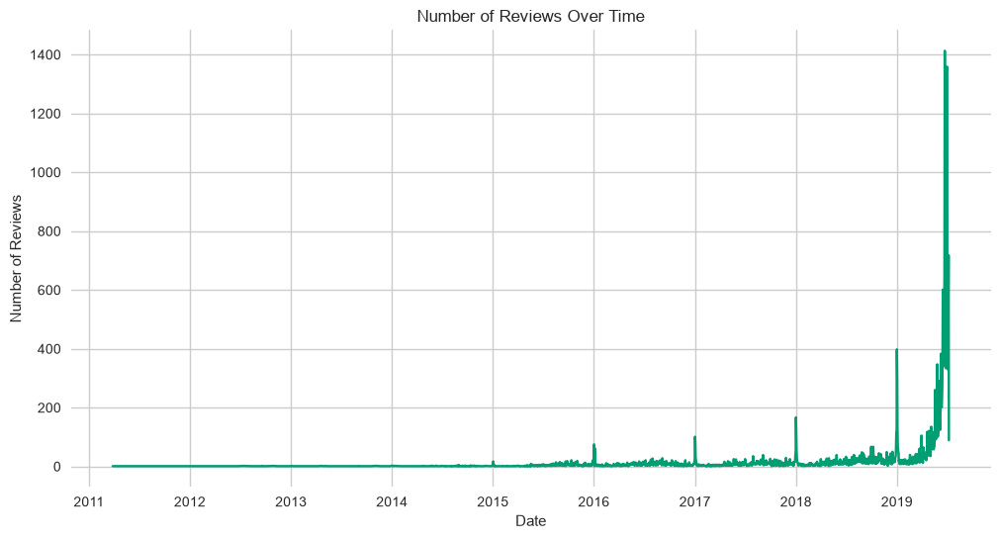

In [18]:
# Converting the 'last_review' column to datetime format
#This will also be utilised later during teh data tarnsformation
df['last_review'] = pd.to_datetime(df['last_review'])
# Sortting the df by the 'last_review' column
df = df.sort_values(by = 'last_review')
# Grouping the dfby the 'last_review' column and counting # reviews
reviews_by_date = df.groupby('last_review').size().reset_index(name = 'num_reviews')
# Setting the colorblind palette
sns.set_palette("colorblind")
# Getting the third color from the palette
color = sns.color_palette()[2]
# Creating the time series plot using Seaborn
sns.set_style('whitegrid')
fig, ax = plt.subplots(figsize = (12,6))
sns.lineplot(x = reviews_by_date['last_review'],
             y = reviews_by_date['num_reviews'], color = color, ax = ax)
ax.set_title('Number of Reviews Over Time')
ax.set_xlabel('Date')
ax.set_ylabel('Number of Reviews')
plt.show();

##### Correlation Matrix.

Highest correlations were between reviews_per_month & number_of_reviews(0.55) and availability_365 & calculated_hostlistings_count(0.23).

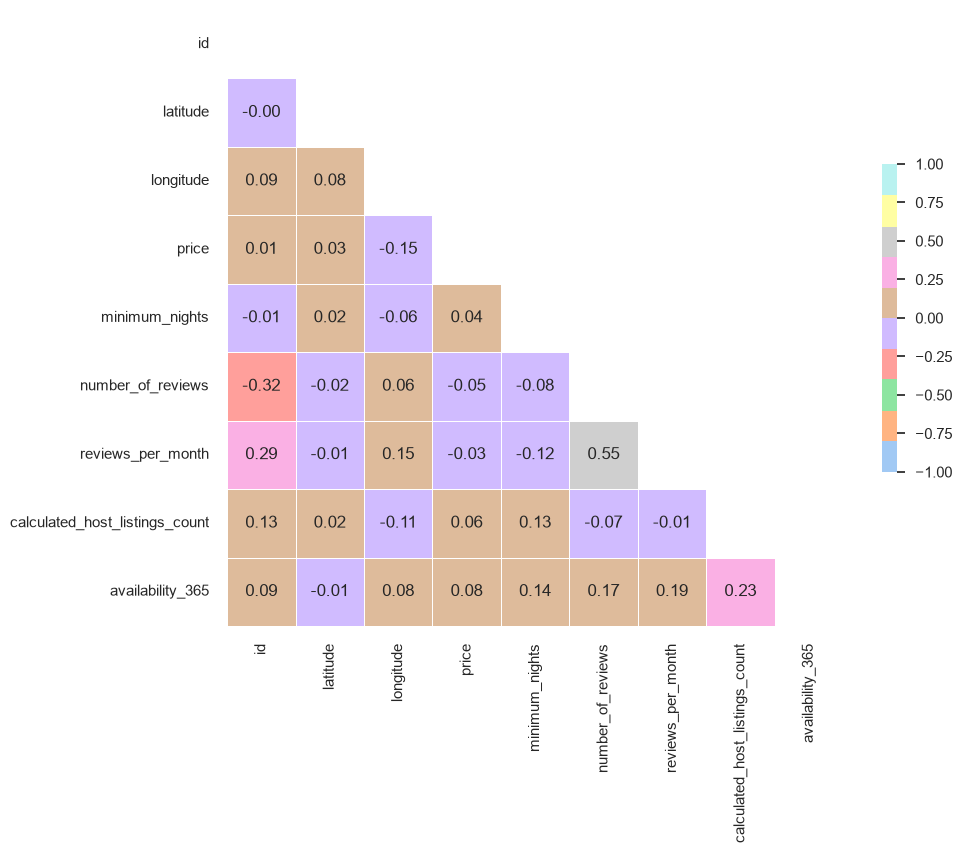

In [19]:
#Correlation Matrix
# Selecting columns with numeric data
numeric_columns = df.select_dtypes(include = [np.number]).columns.tolist()
# Calculating the correlation matrix
corr = df[numeric_columns].corr()
# Masking the upper triangle
mask = np.zeros_like(corr, dtype=np.bool)
mask[np.triu_indices_from(mask)] = True
# Setting the plot up 
sns.set(style = "white")
fig, ax = plt.subplots(figsize = (10, 8))
# Creating a colorblind palette
cmap = sns.color_palette("pastel")
# Creating the heat map
sns.heatmap(corr, mask = mask, cmap = cmap, vmin = -1, 
            vmax = 1, center = 0, square = True,
            linewidths = .5, cbar_kws = {"shrink": .5}, 
            annot = True, fmt = ".2f")
# Rotating the y-axis labels
plt.yticks(rotation = 0)
# Show the plot
plt.show();

##### Histogram of numerical features. 

Most features were highly-skewed and on different scales. Thus, they will be standardised before conducting predictive models.

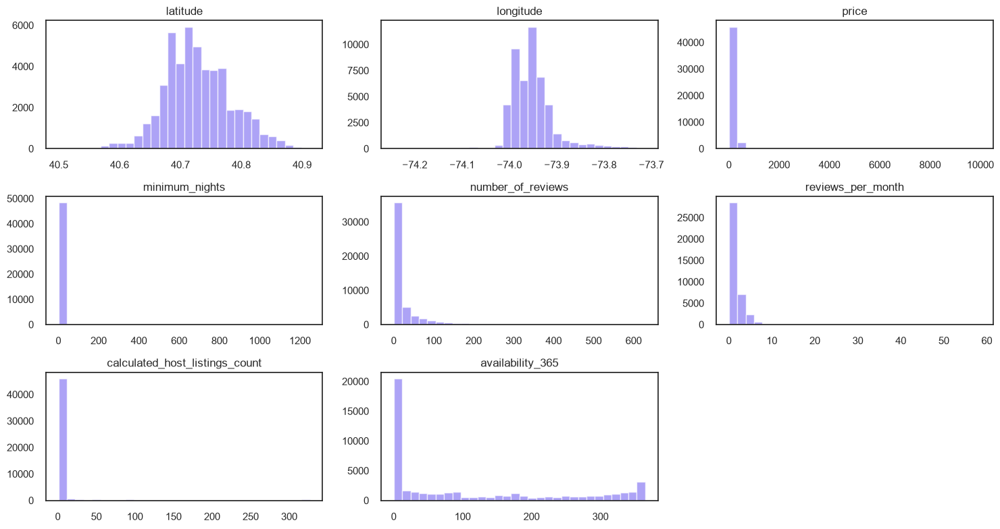

In [20]:
# selecting numerical columns except for 'id'
num_features = df.select_dtypes(include = ['int64', 
                                'float64']).drop('id', axis = 1).columns
# creating subplots with 3 columns
fig, axs = plt.subplots(nrows=len(num_features)//3 + 1, ncols = 3,
                        figsize = (15, 8))
# flattening the axis array
axs = axs.flatten()
# iterating through features and creating a histogram for each
for i, feature in enumerate(num_features):
    axs[i].hist(df[feature], bins = 30, color = '#8a7df3', alpha = 0.7)
    axs[i].set_title(feature, fontsize = 12)
# removing any unused subplots
for i in range(len(num_features), len(axs)):
    fig.delaxes(axs[i])
# adjusting the spacing between subplots
fig.tight_layout()
plt.show();

##### Calculating the % of missing values in each column.

The only columns with missing values are 'last_review' and 'reviews_per_month', both having 20.6% missing values. 

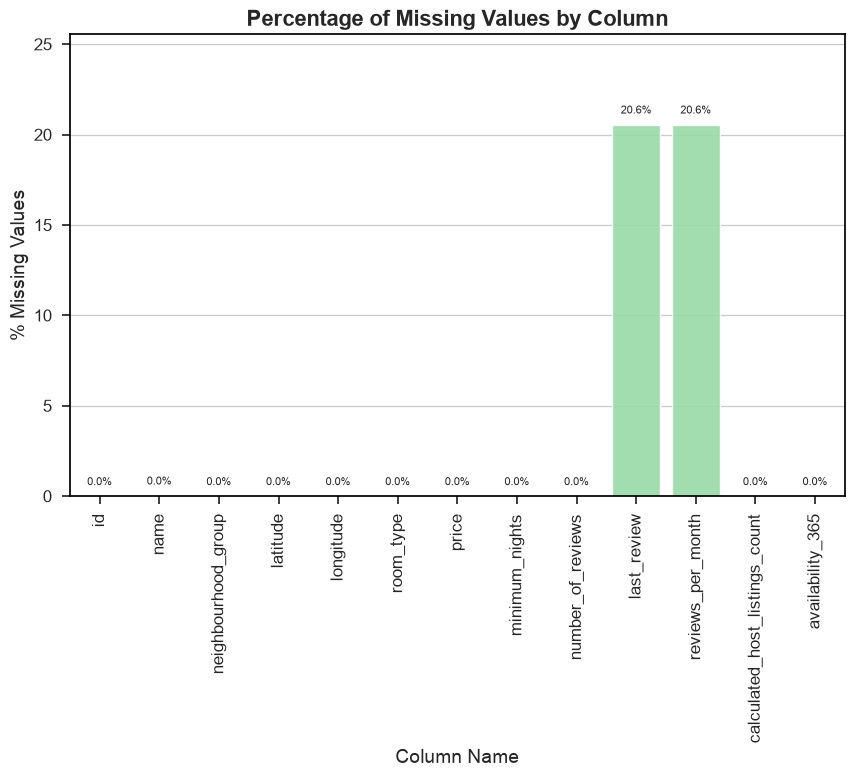

In [21]:
missing_vals = df.isnull().mean() * 100
# Setting style
sns.set_style('whitegrid', {'axes.edgecolor': '0', 
                            'xtick.bottom': True, 
                            'ytick.left': True, 
                            'grid.color': '.8', 
                            'axes.facecolor': 'white'})
# Creating a  bar chart  of missing values
plt.figure(figsize = (10,6))
ax = sns.barplot(x = missing_vals.index, y = missing_vals.values, 
            color = sns.color_palette('pastel')[2], alpha = 0.9)
plt.xticks(rotation = 90, fontsize = 12)
plt.yticks(fontsize = 12)
plt.ylabel('% Missing Values', fontsize = 14)
plt.xlabel('Column Name', fontsize = 14)
plt.title('Percentage of Missing Values by Column', 
          fontsize = 16, fontweight = 'bold')
# Adding a padding to y-axis limits
ax.set_ylim(top=missing_vals.max()+5)
# Adding % values above each bar
for p in ax.patches:
    ax.annotate("{:.1f}%".format(p.get_height()), 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 10), textcoords = 'offset points', 
                fontsize=8)
plt.show();

In [23]:
df.to_csv('data/processed/airbnb_part1_analysis.csv', index=False)